# Task 2: Credit Risk Prediction

## Objective 
### Predict whether a loan applicant is likely to default on a loan.

### import libraries

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('train.csv')   #Import Dataset

In [39]:
df.head()  #check top rows of dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.info()   # Checking datatype Non-Null values columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [3]:
df.isnull().sum()   #Checking Null Values

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

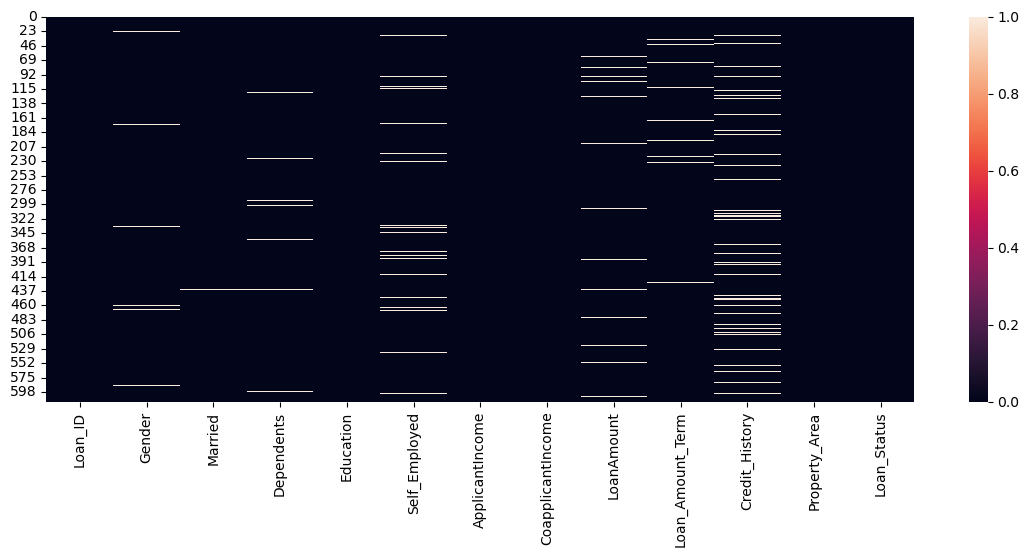

In [7]:
plt.figure(figsize=(14,5))
sns.heatmap(df.isnull())
plt.show()

#### Heatmap Observation
These White spaces are indicating the null values in our dataset

In [3]:
round((df.isnull().sum()/df.shape[0] )*100,2)  #Checking percentage of Null values in each column

Loan_ID              0.00
Gender               2.12
Married              0.49
Dependents           2.44
Education            0.00
Self_Employed        5.21
ApplicantIncome      0.00
CoapplicantIncome    0.00
LoanAmount           3.58
Loan_Amount_Term     2.28
Credit_History       8.14
Property_Area        0.00
Loan_Status          0.00
dtype: float64

In [40]:
df.select_dtypes(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y


### Data CLeaning
In the above data we have some missing values and some columns have with wrong dataype so we have to fix it 

Fill Null Values in Categorical Columns using mode method The .mode() method fills missing values using the most frequently occurring value in a column, which is especially useful for categorical data.

In [3]:
df.select_dtypes(include='object').isnull().sum()

Loan_ID           0
Gender           13
Married           3
Dependents       15
Education         0
Self_Employed    32
Property_Area     0
Loan_Status       0
dtype: int64

In [4]:
categorical_columns = ['Gender', 'Married', 'Self_Employed','Dependents']
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
df.select_dtypes(include='object').isnull().sum()   

Loan_ID          0
Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
Loan_Status      0
dtype: int64

All the missing value of Categorical Columns are Filled Successfully 

In [6]:
df.select_dtypes(include='number').isnull().sum()  #Checkig the Missing values of Numerical Columns

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
dtype: int64

In [7]:
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

we are filling Null value of Credit_History using mode method cause we have only 2 value 0 and 1 so it's some kind of categorical Value and Loan_Amount_Term beacue we have 512 value are 360 out of 615 rows so for that mode() method is best for Filling that values

In [8]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

We fill Null value of LoanAmount with median() casue median give us most Central value. There's possibility of Outliers in this columns that way we use Median

In [9]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

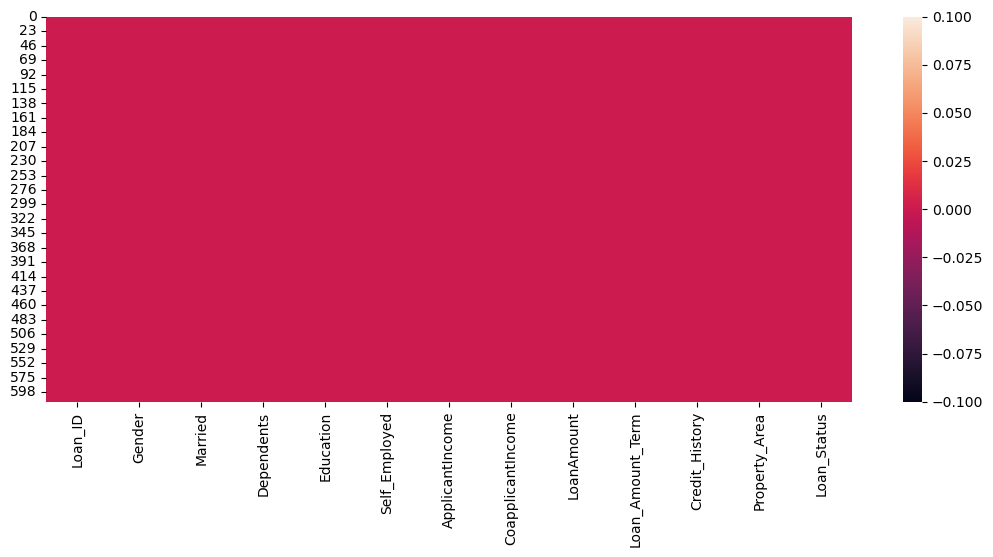

In [10]:
plt.figure(figsize=(13,5))
sns.heatmap(df.isnull())
plt.show()

Heatmap is Clean Indicatiing there is no Null values in our Dataset

#### Cleaned Data
Now the Data is cleaned and ready for further Analysis

### Visiualization Of Data

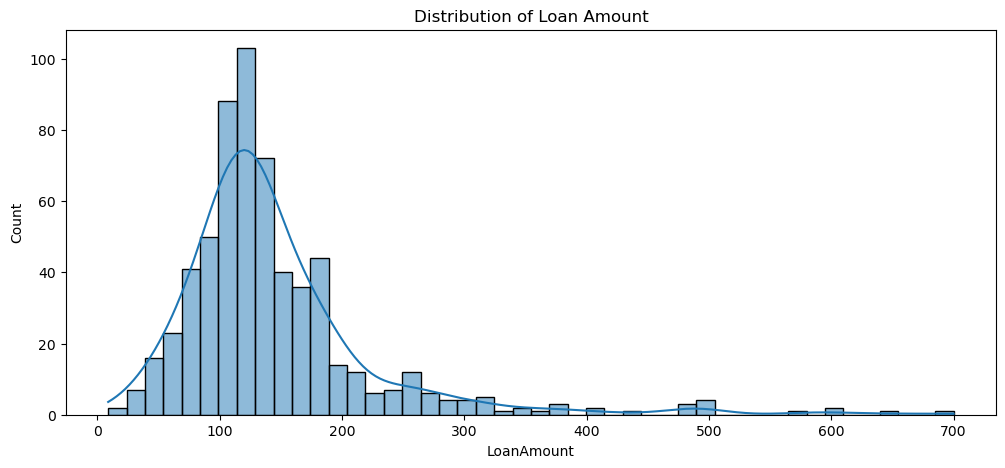

In [24]:
plt.figure(figsize=(12,5))
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

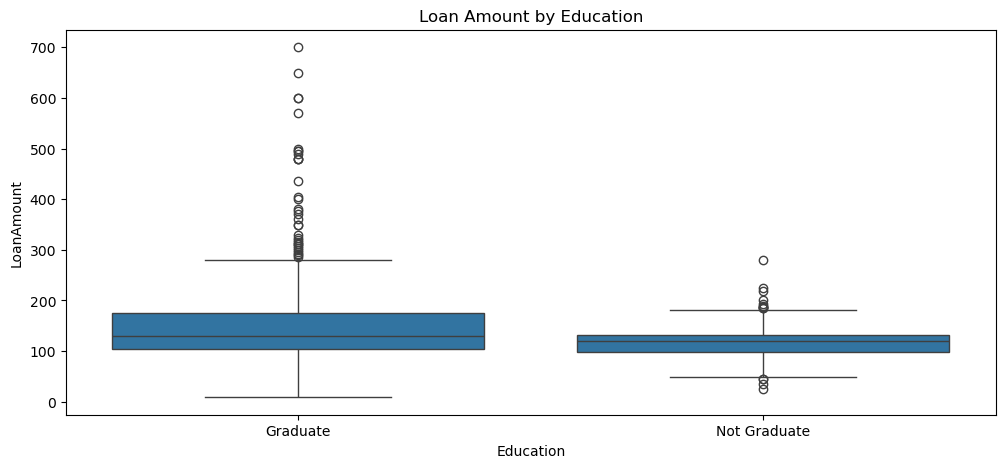

In [26]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Education', y='LoanAmount', data=df)
plt.title("Loan Amount by Education")
plt.show()

In [110]:
#df.to_csv("cleaned_Loan_data.csv", index=False)

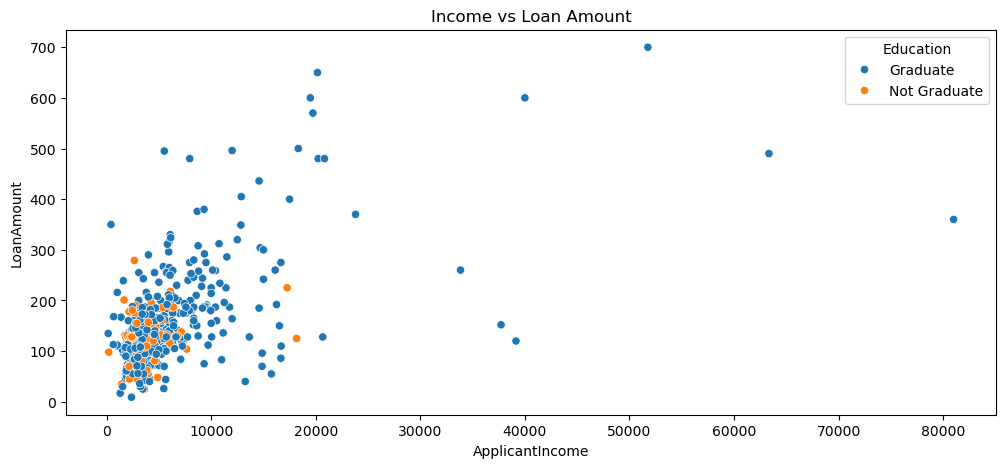

In [27]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df , hue='Education')
plt.title("Income vs Loan Amount")
plt.show()

In [36]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Encode Data

In [10]:
df['Dependents'] = df['Dependents'].replace('3+', '3')

In [11]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [11]:
df = pd.get_dummies(df, columns=["Dependents","Property_Area"], drop_first=True)

In [13]:
df.head(2)

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,Male,No,Graduate,No,5849,0.0,128.0,360.0,1.0,Y,False,False,False,False,True
1,LP001003,Male,Yes,Graduate,No,4583,1508.0,128.0,360.0,1.0,N,True,False,False,False,False


In [12]:
df.drop('Loan_ID', axis=1, inplace=True)  # loan_ID is irrelevent for us we drop it

These Columns has to be Encoded in Binary form for Machine Learning

In [13]:
encod_data = df[['Gender','Married','Education','Self_Employed','Loan_Status']]    #Encode these columns in Binary Format 

### OneHotEncoder

In [14]:
ohe = OneHotEncoder(drop="first")
arr = ohe.fit_transform(encod_data).toarray()
encoded_data = pd.DataFrame(arr, columns=['Gender','Married','Education','Self_Employed','Loan_Status'])
encoded_data

,Gender,Married,Education,Self_Employed,Loan_Status
0,1.0,0.0,0.0,0.0,1.0
1,1.0,1.0,0.0,0.0,0.0
2,1.0,1.0,0.0,1.0,1.0
3,1.0,1.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,1.0
610,1.0,1.0,0.0,0.0,1.0
611,1.0,1.0,0.0,0.0,1.0
612,1.0,1.0,0.0,0.0,1.0


In [15]:
df.drop(['Gender','Married','Education','Self_Employed','Loan_Status'], axis=1, inplace = True)

In [16]:
df = df.astype(int)   #Convert Data into Integer like True/False = 1/0

In [17]:
final_data = pd.concat([df, encoded_data], axis = 1)

In [18]:
final_data.head(3)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents_1,Dependents_2,Dependents_3,Property_Area_Semiurban,Property_Area_Urban,Gender,Married,Education,Self_Employed,Loan_Status
0,5849,0,128,360,1,0,0,0,0,1,1.0,0.0,0.0,0.0,1.0
1,4583,1508,128,360,1,1,0,0,0,0,1.0,1.0,0.0,0.0,0.0
2,3000,0,66,360,1,0,0,0,0,1,1.0,1.0,0.0,1.0,1.0


In [19]:
x = final_data.drop(['Loan_Status'], axis=1)
y = final_data['Loan_Status']

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , random_state= 10)

In [21]:
model = LogisticRegression()

In [22]:
model.fit(x_train, y_train)

C:\Users\Ansar_Mehmood\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
predictions = model.predict(x_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, predictions)*100)   # How much accurate is our model

Accuracy: 79.67479674796748


In [25]:
confusion_matrix(y_test, predictions)

array([[12, 24],
       [ 1, 86]])

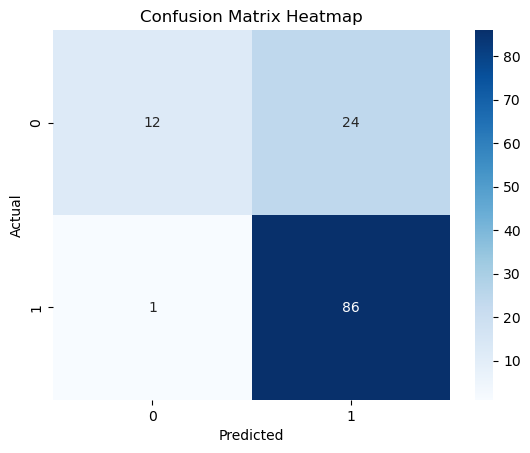

In [31]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")

plt.show()

In [42]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred)*100)
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 71.54471544715447
[[18 18]
 [17 70]]


In [43]:
print("Classification Report (Decision Tree):")
print(classification_report(y_test, dt_pred))

Classification Report (Decision Tree):
              precision    recall  f1-score   support

         0.0       0.51      0.50      0.51        36
         1.0       0.80      0.80      0.80        87

    accuracy                           0.72       123
   macro avg       0.65      0.65      0.65       123
weighted avg       0.71      0.72      0.71       123



### Decison Tree Explanation
A Decision Tree Classifier was trained to predict loan approval status based on applicant information such as income, education, loan amount, and credit history.

The model was evaluated using accuracy score, confusion matrix, and classification report. The Decision Tree model achieved an accuracy of approximately 71.5% on the test dataset.

The classification report showed good performance for approved loan predictions (class 1.0), while performance for rejected loans (class 0.0) was comparatively lower. This indicates that the model was better at identifying approved applicants than rejected applicants.

Overall, the Decision Tree model was able to classify loan applications reasonably well and provided useful insights for credit risk prediction.

## Conclusion
The Logistic Regression model was trained to predict loan approval status using applicant information such as income, education, loan amount, and credit history.
After handling missing values, performing data visualization, and preprocessing the dataset, the model was evaluated using accuracy score and confusion matrix.
The model achieved good prediction performance and correctly classified most loan applications. The confusion matrix showed that only a small number of applications were misclassified.
Overall, the model performed well for basic credit risk prediction.